# Implementattion des equations de la descente de gradient

pour realiser ces taches nous allons structurer notre code de la facon suivante:
- 1 Phase d'initialisation(X) permet d'initialiser les parametres w et b de notre modele.Dans cette fonction nous ferrons passer la matrice X car notre but est d'obtnir un vecteur Y qui contient autant de parametre que l'on trouve de variable dans lamatrice X .
- 2 Algorithme iteratif pour effectuer les taches suivantes:fonction qui represente notre modele(model(X,W,b) elle va contenir notre fonction lineaire(Z=X.W+b)et la fonction d'activation(A=1/(1+exp(-Z))) )--> fonction d'evaluation ou fonction cout (Cost(A,Y) qui permettra d'evaluer les performence du modele en comparent la sortir A au donnees de reference Y) ensuite on va calculer les gradients de cette fonction cout Gradient(A,X,y)-->On va utiliser ces gradient pour mettre a jour les parametre W et b update(W,b,dW,db) de maniere a reduire les erreurs de notre modele.

In [1]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.5/8.3 MB 5.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.3 MB 636.8 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.3 MB 636.8 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.3 MB 636.8 kB/s eta 0:00:12
   ------- -------------------------------- 1.6/8.3 MB 704.7 kB/s eta 0:00:10
   ------- --------------------

In [143]:
!pip install tqdm

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs  #scikit-learn  permet de visualiser les données et de créer des ensembles de données synthétiques pour tester les algorithmes d'apprentissage automatique.
from sklearn.metrics import accuracy_score  #scikit-learn  permet de visualiser les données et de créer des ensembles de données synthétiques pour tester les algorithmes d'apprentissage automatique.
from tqdm import tqdm  #scikit-learn  permet de visualiser les données et de créer des ensembles de données synthétiques pour tester les algorithmes d'apprentissage automatique.

Dimensions de X: (100, 2)
Dimensions de y: (100, 1)


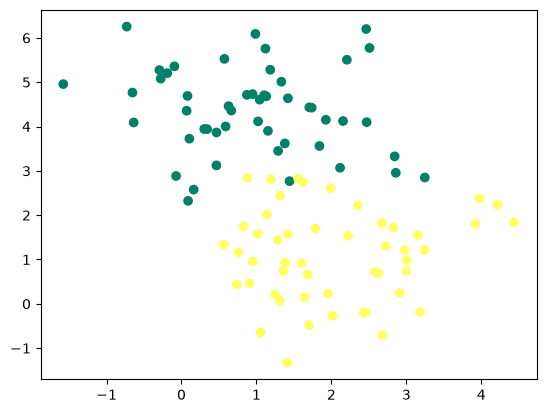

In [3]:
X,y=make_blobs(n_samples=100, n_features=2, centers=2, random_state=0) #génère un ensemble de données synthétiques avec 100 échantillons répartis en 2 clusters.
y=y.reshape((y.shape[0],1)) #redimensionne le vecteur de sortie y pour qu'il ait une forme compatible avec les opérations matricielles ultérieures.

print("Dimensions de X:",X.shape) #affiche les dimensions de la matrice X.
print("Dimensions de y:",y.shape) #affiche les dimensions du vecteur y.

plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='summer') #trace les points avec une couleur selon leur classe.
plt.show()

In [4]:
# creation de la fonction d'inaitailisation

def initialisation(X):
    W = np.random.randn(X.shape[1], 1) # Initialiser les poids avec de petites valeurs aléatoires
    b = np.random.randn(1) # Initialiser le biais avec une petite valeur aléatoire
    return W, b 

In [5]:
# Implementation de la fonction du model
def model(X, W, b):
    Z=X.dot(W) + b  # Calculer la sortie du modèle en effectuant le produit matriciel entre les entrées X et les poids W, puis en ajoutant le biais b.
    A=1/(1+np.exp(-Z))  # Appliquer la fonction d'activation  pour obtenir les probabilités de sortie A.  
    return A  # Retourner les probabilités de sortie.

In [72]:
# implementation de la fonction cout logloss
def log_loss(A, y):
    epsilon = 1e-15  # Ajouter une petite valeur epsilon pour éviter la division par zéro lors du calcul du logarithme.
    m = y.shape[0]
    loss = -(1/m) * np.sum(y * np.log(A + epsilon) + (1 - y) * np.log(1 - A + epsilon))  # Calculer la perte  en utilisant la formule de la log-loss.
    return loss  # Retourner la perte calculée

In [73]:
#Implementation des fonction de gradient 
def gradients(A, X, y):
    m = y.shape[0]
    dW = (1/m) * X.T.dot(A - y)  # Calculer le gradient des poids en utilisant la différence entre les probabilités de sortie A et les étiquettes réelles y.
    db = (1/m) * np.sum(A - y)  # Calculer le gradient du biais en utilisant la somme des différences entre A et y.
    return (dW, db)  # Retourner les gradients calculés pour les poids et le biais.

In [74]:
# Implementation de la fonction de mise à jour des paramètres
def update(W, b, dW, db, learning_rate):
    W -= learning_rate * dW  # Mettre à jour les poids en soustrayant le produit du taux d'apprentissage et du gradient des poids.
    b -= learning_rate * db  # Mettre à jour le biais en soustrayant le produit du taux d'apprentissage et du gradient du biais.
    return (W, b ) # Retourner les paramètres mis à jour.

In [106]:
# prediction
def predict(X, W, b):
    A = model(X, W, b)  # Calculer les probabilités de sortie du modèle.
    predictions = (A > 0.5).astype(int)  # Convertir les probabilités en classes (0 ou 1) en utilisant un seuil de 0.5.
    # print(A)  # Afficher les probabilités de sortie pour le nouvel échantillon.
    return predictions  # Retourner les prédictions finales.

In [ ]:
def train(X, y, learning_rate=0.1, num_iterations=100):
    W, b = initialisation(X)  # Initialiser les poids et le biais.
    losses = []  # Liste pour stocker les pertes à chaque itération.
    acc=[]  # Liste pour stocker les précisions à chaque itération.

    for i in tqdm(range(num_iterations)):
        A = model(X, W, b)  # Calculer les probabilités de sortie du modèle.
        loss = log_loss(A, y)  # Calculer la perte actuelle.
        losses.append(loss)  # Ajouter la perte à la liste des pertes.
        y_pred = predict(X, W, b)  # Faire des prédictions sur les données d'entraînement.
        acc.append(accuracy_score(y, y_pred))  # Calculer et ajouter la précision actuelle à la liste des précisions.
        dW, db = gradients(A, X, y)  # Calculer les gradients des poids et du biais.
        W, b = update(W, b, dW, db, learning_rate)  # Mettre à jour les paramètres.

        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss}, Accuracy = {acc[-1]}")  # Afficher la perte et la précision tous les 100 itérations.


    plt.figure(figsize=(12, 4))  # Créer une figure avec une taille spécifiée.
    plt.subplot(1, 2, 1)  # Créer un sous-graphique pour la perte.
    plt.plot(losses)  # Tracer la courbe de perte au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Loss")  # Étiqueter l'axe des y.
    plt.title("Loss over Iterations")  # Ajouter un titre au graphique.

    plt.subplot(1, 2, 2)  # Créer un sous-graphique pour la précision.
    plt.plot(acc)  # Tracer la courbe de précision au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Accuracy")  # Étiqueter l'axe des y.
    plt.title("Accuracy over Iterations")  # Ajouter un titre au graphique.
    plt.show()  # Afficher le graphique.

    return (W, b)  # Retourner les poids finaux, le biais et la liste des pertes.

100%|██████████| 100/100 [00:00<00:00, 1514.99it/s]


Iteration 0: Loss = 1.4002910517419662, Accuracy = 0.1


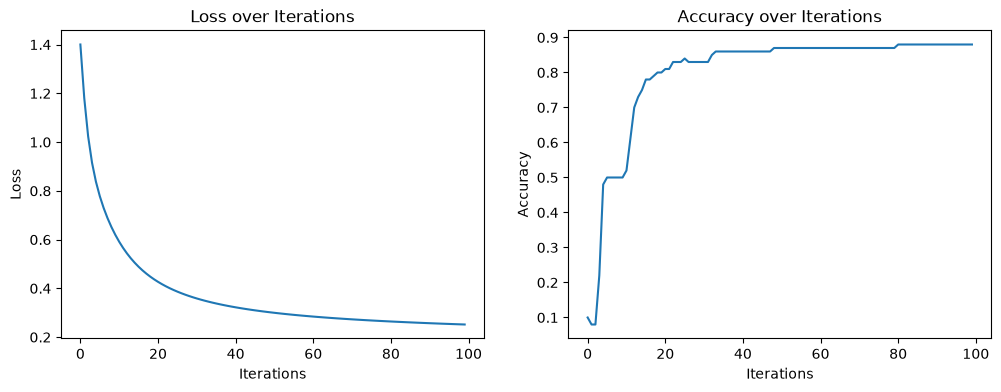

In [155]:
W, b = train(X, y, learning_rate=0.1, num_iterations=100)  # Appeler la fonction d'entraînement avec les données X et y.

[1]


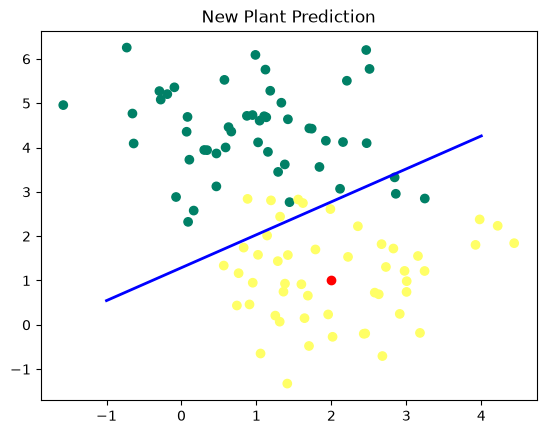

In [110]:
new_plant = np.array([2, 1])  # Définir un nouvel échantillon de plante avec des caractéristiques spécifiques.

# tracer de la frontière de décision
x0=np.linspace(-1, 4, 100)  # Générer 100 points également espacés entre -1 et 4 pour l'axe x.
x1=-(W[0]*x0+b)/W[1]  # Calculer les valeurs correspondantes de l'axe y en utilisant l'équation de la frontière de décision.

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')  # Tracer les points de données d'entraînement avec une couleur selon leur classe.
plt.scatter(new_plant[0], new_plant[1], c='red')  # Tracer le nouvel échantillon de plante.
plt.plot(x0, x1, color='blue', linewidth=2)  # Tracer la frontière de décision en bleu.
plt.title("New Plant Prediction")  # Ajouter un titre au graphique
new_plant_prediction = predict(new_plant, W, b)  # Faire une prédiction pour le nouvel échantillon de plante.
print(new_plant_prediction)

# Tracage de la frontiere de decision
Elle correspond a l'ensemble des points pour lequels Z=0 car c'est l'endroit ou les probabilites sont superieur a 50 % .Car ou le point A atteint 50% le point Z est a 0
on a w1x1+w2x2+b=0


In [111]:
lin=10
h=100
w1=np.linspace(-lin, lin, h)  # Générer 100 points également espacés entre -10 et 10 pour l'axe x.
w2=np.linspace(-lin, lin, h)  # Générer 100 points également

w1, w2 = np.meshgrid(w1, w2)  # Créer une grille de points à partir des vecteurs w1 et w2.
w_final = np.c_[w1.ravel(), w2.ravel()].T  # Aplatir les grilles w1 et w2 et les combiner en une matrice de coordonnées.
w_final.shape

(2, 10000)

In [112]:
b=0
Z=X.dot(w_final)+b
A=1/(1+np.exp(-Z))

epsilon = 1e-15  # Ajouter une petite valeur epsilon pour éviter la division par zéro lors du calcul du logarithme.
m = y.shape[0]
L = -(1/m) * np.sum(y * np.log(A + epsilon) + (1 - y) * np.log(1 - A + epsilon), axis=0).reshape(w1.shape)  # Calculer la perte  en utilisant la formule de la log-loss.

L.shape

(100, 100)

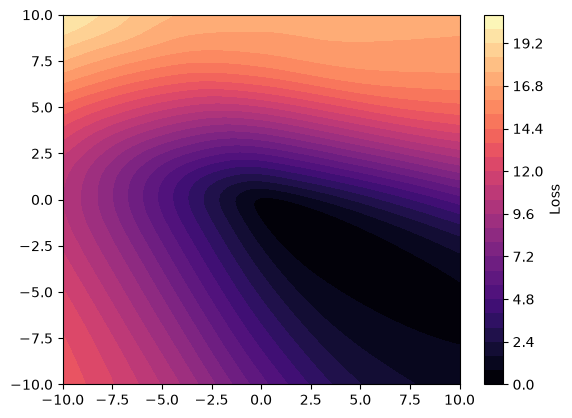

In [93]:
plt.contourf(w1, w2, L,30,cmap='magma')  # Tracer les contours de la fonction de perte L en utilisant une carte de couleurs 'viridis'.
plt.colorbar(label='Loss')  # Ajouter une b arre de couleur pour indiquer les valeurs

# Application de ce model dans la detection des chants ou des chien dans un dataset

In [64]:
!pip install h5py

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 5.6 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   --------- ------------------------------ 0.8/3.2 MB 8.3 MB/s eta 0:00:01
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ---------------- ----------------------- 1.3/3.2 MB 706.1 kB/s eta 0:00:03
   ------------------- -------------------- 1.6/3.2 MB 616.8 kB/s eta 0:00:03
   ------

In [114]:
# importation des data
import h5py
import numpy as np


def load_data():
    train_dataset = h5py.File('Data/trainset.hdf5', "r")
    X_train = np.array(train_dataset["X_train"][:]) # your train set features
    y_train = np.array(train_dataset["Y_train"][:]) # your train set labels

    test_dataset = h5py.File('Data/testset.hdf5', "r")
    X_test = np.array(test_dataset["X_test"][:]) # your train set features
    y_test = np.array(test_dataset["Y_test"][:]) # your train set labels
    
    return X_train, y_train, X_test, y_test

In [115]:
x_train, y_train, x_test, y_test = load_data()  # Charger les ensembles de données d'entraînement et de test à partir des fichiers HDF5.

In [116]:
print(x_train.shape)  # Afficher le nombre de caractéristiques dans l'ensemble de données d'entraînement.
print(y_train.shape)  # Afficher le nombre d'échantillons dans l'ensemble de données d'entraînement.
print(np.unique(y_train, return_counts=True))  # Afficher les classes uniques présentes dans l'ensemble de données d'entraînement.

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [117]:
print(x_test.shape)  # Afficher le nombre de caractéristiques dans l'ensemble de données de test.
print(y_test.shape)  # Afficher le nombre d'échantillons dans l'ensemble de données de test.
print(np.unique(y_test, return_counts=True))  # Afficher les classes uniques présentes dans l'ensemble de données de test.

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([100, 100]))


In [118]:
x_train_reshape=x_train.reshape(x_train.shape[0], -1)/x_train.max()  # Redimensionner et normaliser les données d'entraînement.
x_test_reshape=x_test.reshape(x_test.shape[0], -1)/x_train.max()  # Redimensionner et normaliser les données de test.
x_train_reshape.shape
x_test_reshape.shape

(200, 4096)

In [160]:
def train_neurone(x_train, y_train, x_test, y_test, learning_rate=0.1, num_iterations=100):
    W, b = initialisation(x_train)  # Initialiser les poids et le biais.
    train_losses = []  # Liste pour stocker les pertes à chaque itération.
    train_acc = []  # Liste pour stocker les précisions à chaque itération.
    test_losses = []  # Liste pour stocker les pertes à chaque itération.
    test_acc = []  # Liste pour stocker les précisions à chaque itération.

    for i in tqdm(range(num_iterations)):
        A = model(x_train, W, b)  # Calculer les probabilités de sortie du modèle.
        if i % 10 == 0:
            # train 
            loss = log_loss(A, y_train)  # Calculer la perte actuelle.
            train_losses.append(loss)  # Ajouter la perte à la liste des pertes.
            y_pred = predict(x_train, W, b)  # Faire des prédictions sur les données d'entraînement.
            train_acc.append(accuracy_score(y_train, y_pred))  # Calculer et ajouter la précision actuelle à la liste des précisions.
            
            # test
            A_test = model(x_test, W, b)  # Calculer les probabilités de sortie du modèle pour les données de test.
            test_loss = log_loss(A_test, y_test)  # Calculer la perte actuelle.
            test_losses.append(test_loss)  # Ajouter la perte à la liste des pertes.
            y_pred = predict(x_test, W, b)  # Faire des prédictions sur les données de test.
            test_acc.append(accuracy_score(y_test, y_pred))  # Calculer et ajouter la précision actuelle à la liste des précisions.

        # Mise a jour des paramètres
        dW, db = gradients(A, x_train, y_train)  # Calculer les gradients des poids et du biais.
        W, b = update(W, b, dW, db, learning_rate)  # Mettre à jour les paramètres.

        if i % 1000 == 0:
            print(f"Iteration {i}: Loss = {loss}, Accuracy = {train_acc[-1]}")  # Afficher la perte et la précision tous les 100 itérations.





    plt.figure(figsize=(12, 4))  # Créer une figure avec une taille spécifiée.
    plt.subplot(1, 2, 1)  # Créer un sous-graphique pour la perte.
    plt.plot(train_losses)  # Tracer la courbe de perte au fil des itérations.
    plt.plot(test_losses)  # Tracer la courbe de perte de test au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Train Loss")  # Étiqueter l'axe des y.
    plt.title("Loss over Iterations")  # Ajouter un titre au graphique.

    plt.subplot(1, 2, 2)  # Créer un sous-graphique pour la précision.
    plt.plot(train_acc)  # Tracer la courbe de précision au fil des itérations.
    plt.plot(test_acc)  # Tracer la courbe de précision de test au fil des itérations.
    plt.xlabel("Iterations")  # Étiqueter l'axe des x.
    plt.ylabel("Accuracy")  # Étiqueter l'axe des y.
    plt.title("Accuracy over Iterations")  # Ajouter un titre au graphique.
    plt.show()  # Afficher le graphique.

    return (W, b)  # Retourner les poids finaux, le biais et la liste des pertes.

  0%|          | 26/10000 [00:00<00:38, 258.75it/s]

Iteration 0: Loss = 16.357564312393936, Accuracy = 0.501


 10%|█         | 1010/10000 [00:04<00:39, 230.28it/s]

Iteration 1000: Loss = 2.901485442572805, Accuracy = 0.541


 20%|██        | 2045/10000 [00:08<00:32, 241.53it/s]

...

 80%|████████  | 8049/10000 [00:33<00:07, 257.82it/s]

Iteration 8000: Loss = 1.0974775975977291, Accuracy = 0.681


 90%|█████████ | 9027/10000 [00:37<00:03, 264.22it/s]

Iteration 9000: Loss = 0.9997013893565693, Accuracy = 0.696


100%|██████████| 10000/10000 [00:40<00:00, 243.94it/s]


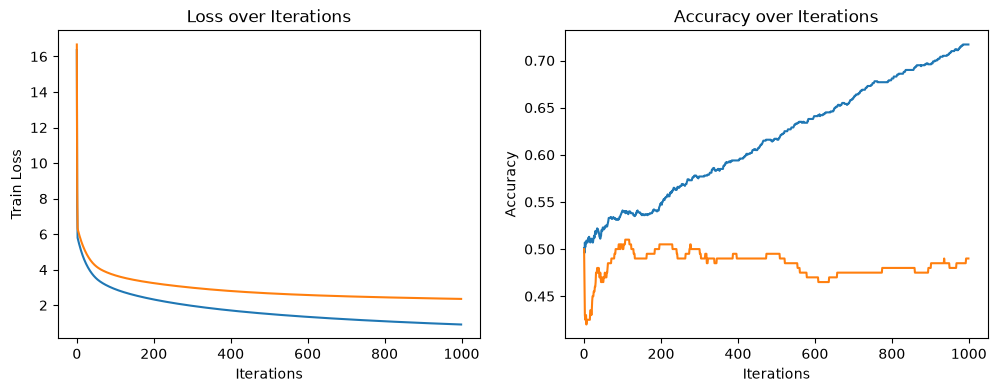

In [162]:
W,b=train_neurone(x_train_reshape, y_train, x_test_reshape, y_test, learning_rate=0.01, num_iterations=10000)  # Appeler la fonction d'entraînement avec les données d'entraînement redimensionnées et normalisées.